<a href="https://colab.research.google.com/github/DeviShree2006/ITA0620/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET
  BloodPressure Cholesterol Smoker CardioRisk
0          High        High    Yes   HighRisk
1          High        High     No   HighRisk
2        Normal        High    Yes   HighRisk
3        Normal        High     No    LowRisk
4        Normal      Normal     No    LowRisk
5          High      Normal     No    LowRisk
6        Normal      Normal    Yes    LowRisk
7          High      Normal    Yes   HighRisk


ENCODED FEATURES
   BloodPressure_High  BloodPressure_Normal  Cholesterol_High  \
0                True                 False              True   
1                True                 False              True   
2               False                  True              True   
3               False                  True              True   
4               False                  True             False   
5                True                 False             False   
6               False                  True             False   
7                True                 F

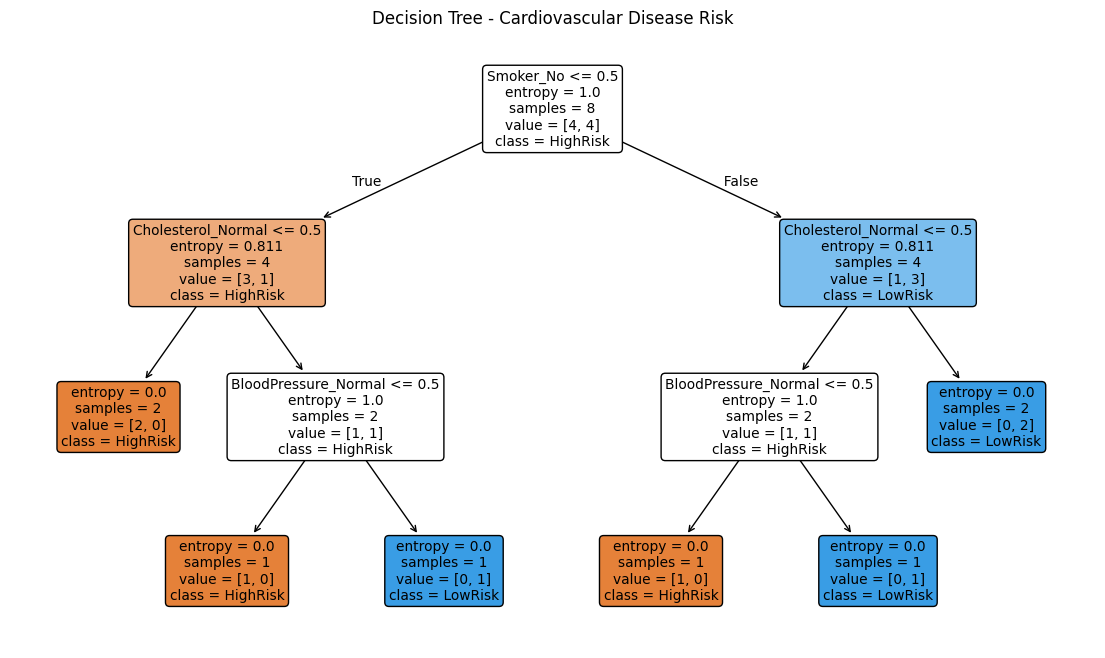


FEATURE IMPORTANCE
BloodPressure_High        : 0.0000
BloodPressure_Normal      : 0.5000
Cholesterol_High          : 0.0000
Cholesterol_Normal        : 0.3113
Smoker_No                 : 0.1887
Smoker_Yes                : 0.0000


PREDICTIONS
  BloodPressure Cholesterol Smoker CardioRisk PredictedRisk
0          High        High    Yes   HighRisk      HighRisk
1          High        High     No   HighRisk      HighRisk
2        Normal        High    Yes   HighRisk      HighRisk
3        Normal        High     No    LowRisk       LowRisk
4        Normal      Normal     No    LowRisk       LowRisk
5          High      Normal     No    LowRisk       LowRisk
6        Normal      Normal    Yes    LowRisk       LowRisk
7          High      Normal    Yes   HighRisk      HighRisk


NEW PATIENT
  BloodPressure Cholesterol Smoker
0          High        High     No

Predicted Cardiovascular Risk: HighRisk


In [8]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
data = {    "BloodPressure": [        "High", "High", "Normal", "Normal",        "Normal", "High", "Normal", "High"    ],    "Cholesterol": [        "High", "High", "High", "High",        "Normal", "Normal", "Normal", "Normal"    ],    "Smoker": [        "Yes", "No", "Yes", "No",        "No", "No", "Yes", "Yes"    ],    "CardioRisk": [        "HighRisk", "HighRisk", "HighRisk", "LowRisk",        "LowRisk", "LowRisk", "LowRisk", "HighRisk"    ] }
df = pd.DataFrame(data)
print("DATASET")
print("=" * 60)
print(df)
X = df[["BloodPressure", "Cholesterol", "Smoker"]]
y = df["CardioRisk"]
X_encoded = pd.get_dummies(X)
print("\n\nENCODED FEATURES")
print("=" * 60)
print(X_encoded)
model = DecisionTreeClassifier( criterion="entropy", random_state=42 )
model.fit(X_encoded, y)
plt.figure(figsize=(14, 8))
plot_tree( model, feature_names=X_encoded.columns, class_names=model.classes_, filled=True, rounded=True)
plt.title("Decision Tree - Cardiovascular Disease Risk")
plt.show()
print("\nFEATURE IMPORTANCE")
print("=" * 60)
for feature, importance in zip( X_encoded.columns, model.feature_importances_ ):
  print(f"{feature:25s} : {importance:.4f}")
predictions = model.predict(X_encoded)
df["PredictedRisk"] = predictions
print("\n\nPREDICTIONS")
print("=" * 60)
print(df)
new_patient = pd.DataFrame({ "BloodPressure": ["High"], "Cholesterol": ["High"], "Smoker": ["No"] })
new_patient_encoded = pd.get_dummies(new_patient)
new_patient_encoded = new_patient_encoded.reindex( columns=X_encoded.columns, fill_value=0 )
prediction = model.predict(new_patient_encoded)
print("\n\nNEW PATIENT")
print("=" * 60)
print(new_patient)
print("\nPredicted Cardiovascular Risk:", prediction[0])